In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Import

In [ ]:
# Import
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import random
from keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dropout

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings("ignore", message="Found untraced functions such as _update_step_xla while saving")

#  quicker running
os.environ['N_JOBS'] = '-1'

# files
# check the feature weight list from PART2-feature selection
data_train = pd.read_csv("data_train.csv")
data_val = pd.read_csv("data_val.csv")
data_test = pd.read_csv("data_test.csv")
features_list = pd.read_csv("features_list_v2.csv")

data_train.drop(columns='Unnamed: 0', inplace=True)
data_val.drop(columns='Unnamed: 0', inplace=True)
data_test.drop(columns='Unnamed: 0', inplace=True)
features_list.drop(columns='Unnamed: 0', inplace=True)

# Get X and Y

In [ ]:
def set_seed(seed_value):
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['PYTHONHASHSEED']=str(seed_value)
    random.seed(seed_value)
    np.random.seed(seed_value)
    tf.random.set_seed(seed_value)

def mydic(ht,df):
  df.loc[len(df)] = ht
  return df

def get_X_Y_by_features_list(d, f):
    d_X = d[f]
    d_Y = d['Y']
    # print(d_X.shape, d_Y.shape)
    return d_X,d_Y

def get_X_Y_all():
    fs = features_list
    f = fs['feature name'].to_list()

    train_X,train_Y = get_X_Y_by_features_list(d=data_train, f=f)
    val_X,val_Y = get_X_Y_by_features_list(d=data_val, f=f)
    test_X,test_Y = get_X_Y_by_features_list(d=data_test, f=f)

    return train_X,train_Y, val_X,val_Y, test_X,test_Y

def get_X_Y_all_n(best_fs=29):
    fs = features_list
    f = fs['feature name'].to_list()[:]
    f = f[:best_fs]

    train_X,train_Y = get_X_Y_by_features_list(d=data_train, f=f)
    val_X,val_Y = get_X_Y_by_features_list(d=data_val, f=f)
    test_X,test_Y = get_X_Y_by_features_list(d=data_test, f=f)

    return train_X,train_Y, val_X,val_Y, test_X,test_Y

set_seed(5240)
train_X,train_Y, val_X,val_Y, test_X,test_Y = get_X_Y_all()

In [ ]:
print("in data_train",train_X.shape,train_Y.shape)
print("in data_validation",val_X.shape,val_Y.shape)
print("in data_test",test_X.shape,test_Y.shape)

in data_train (8696, 41) (8696,)
in data_validation (2175, 41) (2175,)
in data_test (1208, 41) (1208,)


# Proper number of features

In [ ]:
import matplotlib.pyplot as plt
def combinelist(cd):
  num_features = cd['num_features']
  test_loss_lists = cd['test_loss'] 
  test_acc_lists = cd['test_acc'] 
  
 # Plot the test loss and accuracy for different numbers of features
  fig, ax1 = plt.subplots()

  color = 'tab:red'
  ax1.set_xlabel('Number of features')
  ax1.set_ylabel('validation loss', color=color)
  ax1.plot(num_features, test_loss_lists, color=color)
  ax1.tick_params(axis='y', labelcolor=color)

  ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

  color = 'tab:blue'
  ax2.set_ylabel('validation accuracy', color=color)  # we already handled the x-label with ax1
  ax2.plot(num_features, test_acc_lists, color=color)
  ax2.tick_params(axis='y', labelcolor=color)

  fig.tight_layout()  # otherwise the right y-label is slightly clipped
  plt.show()


# A simple model here
#DNN(B)-frs(5240)-[12(relu)-8(relu)-1(sigmoid)]-[ep(8)]
def simply_model(train_X, val_X):
  set_seed(5240)
  # epochs=8,batch_size=32

  # Create the DNN model using TensorFlow-Keras
  model = tf.keras.models.Sequential([
      tf.keras.layers.Dense(12, activation='relu', input_shape=(train_X.shape[1],)),
      tf.keras.layers.Dense(8, activation='relu'),
      tf.keras.layers.Dense(1, activation='sigmoid')
  ])

  # Compile the model
  model.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

  # Train the model
  history = model.fit(
      train_X, train_Y,
      epochs=5, batch_size=32,
      validation_split=0.2,
      verbose=0)

  # Training Performance
  # val_loss,val_acc = history.history['val_loss'][-1], history.history['val_accuracy'][-1]

  # Evaluate the model on the test set
  test_loss, test_acc = model.evaluate(val_X, val_Y, verbose=0)

  return test_loss, test_acc

def exam_modeling():
  get_X_Y_all()
  fs_len=len(features_list)
  fs = features_list['feature name'].to_list()

  # record
  s_h=pd.DataFrame(columns=['num_features','test_loss','test_acc'])

  for thre in range(5,fs_len+1,2):
    newf = fs[:thre]

    # Use simple model when features vary
    test_loss, test_acc = simply_model(train_X[newf], val_X[newf])

    ht=[thre,test_loss, test_acc]
    s_h = mydic(ht,s_h)

  return s_h  

In [ ]:
s_h = exam_modeling()

Find the optimal number of features with the hightest accuracy!
     num_features  test_loss  test_acc
12          29.0   0.602451  0.681379


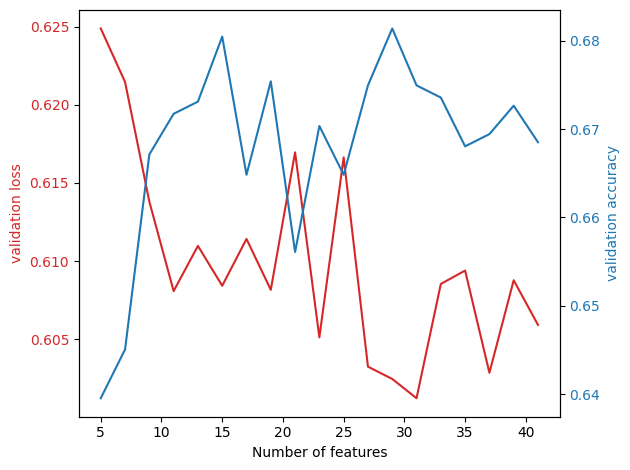

In [ ]:
# obtain the best nember of features
sh11 = s_h.sort_values('test_acc',ascending=False)
best_fs = sh11.head(1)['num_features'] # 29
# plot
print('Find the optimal number of features with the hightest accuracy!\n',sh11.head(1))
combinelist(s_h)

Finding:
Features, ranking TOP29 in the weight list, will be used in the following process.

# DNN modeling

some functions

In [ ]:
def generate_cd(num_features, test_loss_lists, test_acc_lists):
  cd = pd.DataFrame()
  cd['num_features'] = num_features
  cd['test_loss_lists'] = test_loss_lists
  cd['test_acc_lists'] = test_acc_lists
  return cd

def earlystopping_rst(history, early_stopping):
    es_rst = {}

    # Get the epoch at which training stopped
    es_rst['stopped_epoch'] = early_stopping.stopped_epoch

    # Get the history of the validation loss
    val_loss_history = history.history['val_loss']

    # Get the value of the validation loss at the last epoch
    es_rst['last_val_loss'] = val_loss_history[es_rst['stopped_epoch']]

    # Get the value of the validation loss at the best epoch
    es_rst['best_val_loss'] = min(val_loss_history)

    # Print the results
    # print("Training stopped at epoch: ", es_rst['stopped_epoch'])
    # print("Last validation loss: ", es_rst['last_val_loss'])
    # print("Best validation loss: ", es_rst['best_val_loss'])

    return es_rst

## Based model

testing base model: # DNN(B)-frs(5240)-[12(relu)-8(relu)-1(sigmoid)]-[ep(30)]

## Search based model

In [ ]:
# create history doc
b_h = pd.DataFrame(columns=['layer','epochs','batch_size','val_loss','val_acc','test_loss','test_acc'])
l2_h = pd.DataFrame(columns=['layer','epochs','batch_size','val_loss','val_acc','test_loss','test_acc'])
d_h = pd.DataFrame(columns=['layer','epochs','batch_size','val_loss','val_acc','test_loss','test_acc'])


In [ ]:
# Here are 3 modeling function
# Base model, L2-regularized model, Dropout model

# Base model--------------------------------------------------------------------------------
def m1(ly,epochs=30,batch_size=32,b_h=b_h):

  # set random seed
  set_seed(5240)
  # obtain X,Y
  get_X_Y_all_n(29)

  # Create the DNN model using TensorFlow-Keras
  model = tf.keras.models.Sequential()
  model.add(tf.keras.layers.Dense(ly[0][0], activation=ly[0][1], input_shape=(train_X.shape[1],)))
  t=len(ly)
  for i in range(1,t):
      model.add(tf.keras.layers.Dense(ly[i][0], activation=ly[i][1]))

  # Compile the model
  model.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

  # Define early stopping callback
  early_stopping = EarlyStopping(monitor='val_loss', patience=20)
  
  # Train the model
  history = model.fit(
      train_X, train_Y,
      epochs=epochs, batch_size=batch_size,
      validation_data=(val_X, val_Y),
      callbacks=[early_stopping],
      verbose=0)

  # early stopping
  es_rst = earlystopping_rst(history, early_stopping)

  # Training Performance
  val_loss,val_acc = history.history['val_loss'][-1], history.history['val_accuracy'][-1]

  # Evaluate the model on the test set
  test_loss, test_acc = model.evaluate(test_X, test_Y, verbose=0)
  
  print("Evaluation Result (test dataset):")
  print(f'Test loss and Test accuracy: {test_loss:.3f}, {test_acc:.3f}')
  print("******************")
  # record
  hist=[ly,epochs,batch_size,val_loss,val_acc,test_loss, test_acc]
  b_h = mydic(hist,b_h)

  return model,b_h

# L1-regularized model， regularizers.l1(0.001)--------------------------------------------------------------------------------
def m2(ly,epochs=30,batch_size=32,l2_h=l2_h):
  set_seed(5240)
  get_X_Y_all_n(29)

  # Create the DNN model using TensorFlow-Keras
  model = tf.keras.models.Sequential()

  model.add(tf.keras.layers.Dense(ly[0][0], activation=ly[0][1], 
                                  kernel_regularizer=regularizers.l1(0.001),
                                  input_shape=(train_X.shape[1],)))
  t=len(ly)
  for i in range(1,t):
      model.add(tf.keras.layers.Dense(ly[i][0], activation=ly[i][1], kernel_regularizer=regularizers.l1(0.001)))

  # Compile the model
  model.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

  # Define early stopping callback
  early_stopping = EarlyStopping(monitor='val_loss', patience=20)
  
  # Train the model
  history = model.fit(
      train_X, train_Y,
      epochs=epochs, batch_size=32,
      validation_data=(val_X, val_Y),
      callbacks=[early_stopping],
      verbose=0)

  # early stopping
  es_rst = earlystopping_rst(history, early_stopping)

  # Training Performance
  val_loss,val_acc = history.history['val_loss'][-1], history.history['val_accuracy'][-1]

  # Evaluate the model on the test set
  test_loss, test_acc = model.evaluate(test_X, test_Y, verbose=0)
  
  print("Evaluation Result (test dataset):")
  print(f'Test loss and Test accuracy: {test_loss:.3f}, {test_acc:.3f}')
  print("******************")
  hist=[ly,epochs,batch_size,val_loss,val_acc,test_loss, test_acc]
  l2_h = mydic(hist,l2_h) 

  return model,l2_h

# Dropout model， Dropout(0.1)--------------------------------------------------------------------------------
def m3(ly,epochs=30,batch_size=32,d_h=d_h):
  set_seed(5240)
  get_X_Y_all_n(29)

  # Create the DNN model using TensorFlow-Keras
  model = tf.keras.models.Sequential()

  model.add(tf.keras.layers.Dense(ly[0][0], activation=ly[0][1], 
                                  input_shape=(train_X.shape[1],)))
  model.add(Dropout(0.1))

  t=len(ly)
  for i in range(1,t):
      model.add(tf.keras.layers.Dense(ly[i][0], activation=ly[i][1], kernel_regularizer=regularizers.l2(0.01)))
      model.add(Dropout(0.1))

  # Compile the model
  model.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

  # Define early stopping callback
  early_stopping = EarlyStopping(monitor='val_loss', patience=20)
  
  # Train the model
  history = model.fit(
      train_X, train_Y,
      epochs=epochs, batch_size=32,
      validation_data=(val_X, val_Y),
      callbacks=[early_stopping],
      verbose=0)

  # early stopping
  es_rst = earlystopping_rst(history, early_stopping)

  # Training Performance
  val_loss,val_acc = history.history['val_loss'][-1], history.history['val_accuracy'][-1]

  # Evaluate the model on the test set
  test_loss, test_acc = model.evaluate(test_X, test_Y, verbose=0)

  print("Evaluation Result (test dataset):")
  print(f'Test loss and Test accuracy: {test_loss:.3f}, {test_acc:.3f}')
  print("******************")
  hist=[ly,epochs,batch_size,val_loss,val_acc,test_loss, test_acc]
  d_h = mydic(hist,d_h) 

  return model,d_h


## Experiment 

small value of both layers and neurons

In [ ]:
#DNN(B)-frs(5240)-[12(relu)-8(relu)-1(sigmoid)]-[ep(150)]
ly1=[[12,'relu'],[8,'relu'],[1,'sigmoid']]
m11, b_h  = m1(ly1,epochs=30,batch_size=40) 
m22, l2_h = m2(ly1,epochs=30,batch_size=40)
m33, d_h = m3(ly1,epochs=30,batch_size=40) 


Evaluation Result (test dataset):
Test loss and Test accuracy: 0.575, 0.703
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.611, 0.701
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.610, 0.702
******************


In [ ]:
c

40

In [ ]:
b_h

,layer,epochs,batch_size,val_loss,val_acc,test_loss,test_acc
0,"[[12, relu], [8, relu], [1, sigmoid]]",30,40,0.588350,0.691954,0.575489,0.702815
1,"[[20, relu], [12, relu], [8, relu], [1, sigmoid]]",30,40,0.566329,0.724598,0.568962,0.714404
2,"[[20, relu], [8, relu], [12, relu], [1, sigmoid]]",30,40,0.575790,0.708506,0.565358,0.708609
3,"[[30, relu], [12, relu], [24, relu], [12, relu...",30,40,0.586152,0.720460,0.592949,0.695364
4,"[[4, relu], [4, relu], [6, relu], [1, sigmoid]]",30,40,0.593751,0.690575,0.591289,0.681291
5,"[[8, relu], [16, relu], [32, relu], [32, relu]...",30,40,0.585899,0.702529,0.596105,0.698676
6,"[[85, relu], [64, relu], [32, relu], [1, sigmo...",30,40,0.795825,0.692874,0.739458,0.703642
7,"[[120, relu], [85, relu], [64, relu], [32, rel...",30,40,1.413192,0.684598,1.331259,0.685430
8,"[[180, relu], [120, relu], [85, relu], [64, re...",30,40,1.457744,0.703448,1.445611,0.692881
9,"[[240, relu], [120, relu], [85, relu], [64, re...",30,40,1.467441,0.702069,1.314986,0.702815


In [ ]:
ly1=[[20,'relu'],[12,'relu'],[8,'relu'],[1,'sigmoid']]
m11, b_h  = m1(ly1,epochs=30,batch_size=40) 
m22, l2_h = m2(ly1,epochs=30,batch_size=40)
m33, d_h = m3(ly1,epochs=30,batch_size=40) 


Evaluation Result (test dataset):
Test loss and Test accuracy: 0.569, 0.714
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.606, 0.709
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.616, 0.701
******************


In [ ]:
ly1=[[20,'relu'],[8,'relu'],[12,'relu'],[1,'sigmoid']]
m11, b_h  = m1(ly1,epochs=30,batch_size=40) 
m22, l2_h = m2(ly1,epochs=30,batch_size=40)
m33, d_h = m3(ly1,epochs=30,batch_size=40) 


Evaluation Result (test dataset):
Test loss and Test accuracy: 0.565, 0.709
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.600, 0.713
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.689, 0.577
******************


In [ ]:
ly1=[[30,'relu'],[12,'relu'],[24,'relu'],[12,'relu'],[8,'relu'],[1,'sigmoid']]
m11, b_h  = m1(ly1,epochs=30,batch_size=40) 
m22, l2_h = m2(ly1,epochs=30,batch_size=40)
m33, d_h = m3(ly1,epochs=30,batch_size=40) 


Evaluation Result (test dataset):
Test loss and Test accuracy: 0.593, 0.695
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.612, 0.720
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.689, 0.577
******************


In [ ]:
ly1=[[4,'relu'],[4,'relu'],[6,'relu'],[1,'sigmoid']]
m11, b_h  = m1(ly1,epochs=30,batch_size=40) 
m22, l2_h = m2(ly1,epochs=30,batch_size=40)
m33, d_h = m3(ly1,epochs=30,batch_size=40) 

Evaluation Result (test dataset):
Test loss and Test accuracy: 0.591, 0.681
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.595, 0.704
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.638, 0.677
******************


In [ ]:
ly1=[[8,'relu'],[16,'relu'],[32,'relu'],[32,'relu'],[64,'relu'],[1,'sigmoid']]
m11, b_h  = m1(ly1,epochs=30,batch_size=40) 
m22, l2_h = m2(ly1,epochs=30,batch_size=40)
m33, d_h = m3(ly1,epochs=30,batch_size=40) 

Evaluation Result (test dataset):
Test loss and Test accuracy: 0.596, 0.699
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.615, 0.707
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.689, 0.577
******************


lager value of both layers and neurons

In [ ]:
#DNN(B)-frs(5240)-[85(relu)-64(relu)-32(relu)-1(sigmoid)]-[ep(150)-bs(10)]
ly1=[[85,'relu'],[64,'relu'],[32,'relu'],[1,'sigmoid']]
m11, b_h  = m1(ly1,epochs=30,batch_size=40) 
m22, l2_h = m2(ly1,epochs=30,batch_size=40)
m33, d_h = m3(ly1,epochs=30,batch_size=40) 

Evaluation Result (test dataset):
Test loss and Test accuracy: 0.739, 0.704
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.608, 0.713
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.609, 0.700
******************


In [ ]:
ly1=[[120,'relu'],[85,'relu'],[64,'relu'],[32,'relu'],[1,'sigmoid']]
m11, b_h  = m1(ly1,epochs=30,batch_size=40) 
m22, l2_h = m2(ly1,epochs=30,batch_size=40)
m33, d_h = m3(ly1,epochs=30,batch_size=40) 

Evaluation Result (test dataset):
Test loss and Test accuracy: 1.331, 0.685
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.612, 0.709
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.611, 0.718
******************


In [ ]:
ly1=[[180,'relu'],[120,'relu'],[85,'relu'],[64,'relu'],[32,'relu'],[1,'sigmoid']]
m11, b_h  = m1(ly1,epochs=30,batch_size=40) 
m22, l2_h = m2(ly1,epochs=30,batch_size=40)
m33, d_h = m3(ly1,epochs=30,batch_size=40)  


Evaluation Result (test dataset):
Test loss and Test accuracy: 1.446, 0.693
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.621, 0.696
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.627, 0.719
******************


In [ ]:
ly1=[[240,'relu'],[120,'relu'],[85,'relu'],[64,'relu'],[32,'relu'],[1,'sigmoid']]
m11, b_h  = m1(ly1,epochs=30,batch_size=40) 
m22, l2_h = m2(ly1,epochs=30,batch_size=40)
m33, d_h = m3(ly1,epochs=30,batch_size=40) 


Evaluation Result (test dataset):
Test loss and Test accuracy: 1.315, 0.703
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.627, 0.690
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.625, 0.714
******************


In [ ]:
ly1=[[240,'relu'],[180,'relu'],[124,'relu'],[60,'relu'],[32,'relu'],[1,'sigmoid']]
m11, b_h  = m1(ly1,epochs=30,batch_size=40) 
m22, l2_h = m2(ly1,epochs=30,batch_size=40)
m33, d_h = m3(ly1,epochs=30,batch_size=40) 


Evaluation Result (test dataset):
Test loss and Test accuracy: 1.377, 0.696
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.614, 0.708
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.616, 0.724
******************


In [ ]:
ly1=[[240,'relu'],[180,'relu'],[150,'relu'],[80,'relu'],[32,'relu'],[1,'sigmoid']]
m11, b_h  = m1(ly1,epochs=30,batch_size=40) 
m22, l2_h = m2(ly1,epochs=30,batch_size=40)
m33, d_h = m3(ly1,epochs=30,batch_size=40) 


Evaluation Result (test dataset):
Test loss and Test accuracy: 1.470, 0.703
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.636, 0.692
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.618, 0.716
******************


In [ ]:
#DNN(B)-frs(5240)-[([240,'relu']-[180,'relu']-[64,'relu']-[32,'relu']-[24,'relu']-1(sigmoid)]-[ep(30)]
ly1=[[240,'relu'],[180,'relu'],[64,'relu'],[32,'relu'],[24,'relu'],[1,'sigmoid']]
m11, b_h  = m1(ly1,epochs=30,batch_size=c) 
m22, l2_h = m2(ly1,epochs=30,batch_size=c)
m33, d_h = m3(ly1,epochs=30,batch_size=c) 


Evaluation Result (test dataset):
Test loss and Test accuracy: 1.370, 0.705
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.631, 0.697
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.624, 0.709
******************


In [ ]:
#DNN(B)-frs(5240)-[[240,'relu']-[180,'relu']-[64,'relu']-[32,'relu']-[24,'relu']-1(sigmoid)]-[ep(30)]
ly1=[[280,'relu'],[240,'relu'],[180,'relu'],[64,'relu'],[32,'relu'],[24,'relu'],[1,'sigmoid']]
m11, b_h  = m1(ly1,epochs=30,batch_size=40) 
m22, l2_h = m2(ly1,epochs=30,batch_size=40)
m33, d_h = m3(ly1,epochs=30,batch_size=40) 


Evaluation Result (test dataset):
Test loss and Test accuracy: 1.550, 0.703
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.698, 0.577
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.689, 0.577
******************


In [ ]:
ly1=[[64'relu']-[85,'relu']-[120,'relu']-[32,'relu'],[1,'sigmoid']]
m11, b_h  = m1(ly1,epochs=30,batch_size=40) 
m22, l2_h = m2(ly1,epochs=30,batch_size=40)
m33, d_h = m3(ly1,epochs=30,batch_size=40) 

## Fine tunning


DNN(B)-frs(5240)-[([120,'relu']-[85,'relu']-[64,'relu']-[32,'relu']-1(sigmoid)]-[ep(30)]

In [ ]:
# DNN(B)-frs(5240)-[[120,'relu']-[85,'relu']-[64,'relu']-[32,'relu']-1(sigmoid)]-[ep(30)]
for a in range(90,150,15):
  for b in range(64,120,15):
    for c in [20,40]:
      print('-------------------------')
      print(a,b,c)
      ly1=[[a,'relu'],[85,'relu'],[b,'relu'],[32,'relu'],[1,'sigmoid']]
      m11, b_h  = m1(ly1,epochs=30,batch_size=c) 
      m22, l2_h = m2(ly1,epochs=30,batch_size=c)
      m33, d_h = m3(ly1,epochs=30,batch_size=c) 

      

-------------------------
90 64 20
Evaluation Result (test dataset):
Test loss and Test accuracy: 1.234, 0.717
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.609, 0.703
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.610, 0.719
******************
-------------------------
90 64 40
Evaluation Result (test dataset):
Test loss and Test accuracy: 1.154, 0.690
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.612, 0.704
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.618, 0.712
******************
-------------------------
90 79 20
Evaluation Result (test dataset):
Test loss and Test accuracy: 1.090, 0.714
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.600, 0.715
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.612, 0.720
******************
-------------------------
90 79 40
Evalu

In [ ]:
for a in [120,135]:
  for b in [79,94]:
    for e in [30,80,120,160,250]:
      print('-------------------------')
      print(a,b,e)
      ly1=[[a,'relu'],[85,'relu'],[b,'relu'],[32,'relu'],[1,'sigmoid']]
      m11, b_h  = m1(ly1,epochs=30,batch_size=40) 
      m22, l2_h = m2(ly1,epochs=30,batch_size=40)
      m33, d_h = m3(ly1,epochs=30,batch_size=40) 


-------------------------
120 79 30
Evaluation Result (test dataset):
Test loss and Test accuracy: 1.220, 0.685
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.613, 0.700
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.608, 0.728
******************
-------------------------
120 79 80
Evaluation Result (test dataset):
Test loss and Test accuracy: 1.105, 0.709
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.612, 0.713
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.618, 0.711
******************
-------------------------
120 79 120
Evaluation Result (test dataset):
Test loss and Test accuracy: 1.115, 0.690
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.622, 0.709
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.613, 0.719
******************
-------------------------
120 79 160

In [ ]:
# DNN(B)-frs(5240)-[([120,'relu']-[85,'relu']-[64,'relu']-[32,'relu']-1(sigmoid)]-[ep(30)]
for a in range(90,150,15):
    print('-------------------------')
    print(a)
    ly1=[[a,'relu'],[85,'relu'],[b,'relu'],[32,'relu'],[1,'sigmoid']]
    m11, b_h  = m1(ly1,epochs=30,batch_size=40) 
    m22, l2_h = m2(ly1,epochs=30,batch_size=40)
    m33, d_h = m3(ly1,epochs=30,batch_size=40) 


-------------------------
90
Evaluation Result (test dataset):
Test loss and Test accuracy: 1.244, 0.699
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.623, 0.696
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.610, 0.724
******************
-------------------------
105
Evaluation Result (test dataset):
Test loss and Test accuracy: 1.142, 0.732
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.614, 0.708
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.614, 0.716
******************
-------------------------
120
Evaluation Result (test dataset):
Test loss and Test accuracy: 1.193, 0.703
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.616, 0.698
******************
Evaluation Result (test dataset):
Test loss and Test accuracy: 0.610, 0.719
******************
-------------------------
135
Evaluation Result (test da

# Export excel file

Tips: correct the name of file l2_h

In [ ]:
l1_h=l2_h

In [ ]:
b_h.sort_values(by=['test_acc']).head(2)

,layer,epochs,batch_size,val_loss,val_acc,test_loss,test_acc
19,"[[90, relu], [85, relu], [94, relu], [32, relu...",30,40,1.175708,0.691954,1.177159,0.672185
4,"[[4, relu], [4, relu], [6, relu], [1, sigmoid]]",30,40,0.593751,0.690575,0.591289,0.681291


In [ ]:
l1_h.sort_values(by=['test_acc']).head(2)

,layer,epochs,batch_size,val_loss,val_acc,test_loss,test_acc
13,"[[280, relu], [240, relu], [180, relu], [64, r...",30,40,0.703460,0.559080,0.698405,0.576987
9,"[[240, relu], [120, relu], [85, relu], [64, re...",30,40,0.624535,0.696552,0.627268,0.690397


In [ ]:
d_h.sort_values(by=['test_acc']).head(2)

,layer,epochs,batch_size,val_loss,val_acc,test_loss,test_acc
2,"[[20, relu], [8, relu], [12, relu], [1, sigmoid]]",30,40,0.690158,0.55908,0.689127,0.576987
3,"[[30, relu], [12, relu], [24, relu], [12, relu...",30,40,0.690229,0.55908,0.689226,0.576987


In [ ]:
b_h.to_excel('base_model_recording.xlsx')

In [ ]:
l1_h.to_excel('L1_regularized_model_recording.xlsx')

In [ ]:
d_h.to_excel('Dropout_model_recording.xlsx')